In [113]:
import pandas as pd
import matplotlib.pyplot as plt
# 设置最多显示200行和50列（无省略号）
pd.set_option('display.max_rows', 200)      # 最大行数
pd.set_option('display.max_columns', 50)    # 最大列数
pd.set_option('display.width', None)        # 自动适应终端宽度
pd.set_option('display.max_colwidth', None) # 列内容不被截断（可选）

import numpy as np

In [102]:
import pandas as pd, glob, datetime as dt
import os
dictionary = '../../crypto_futures_data/SOLUSDT/'
start, end = dt.date(2024,8,1), dt.date(2025,8,24)
df = pd.concat([pd.read_csv(f).assign(date=f[-14:-4])
                for f in glob.glob(os.path.join(dictionary, 'SOLUSDT-bookDepth-*.csv'))
                if start <= dt.datetime.strptime(f[-14:-4], '%Y-%m-%d').date() <= end])

In [103]:
df['mid_price'] = (df['avg_price_1'] + df['avg_price_-1']) / 2
df.timestamp = pd.to_datetime(df.timestamp)


In [107]:
df['ts_1min'] = df.timestamp.dt.ceil('1min')
Omin_df = df.groupby(['ts_1min'])['mid_price'].last()

OminLag60s_df = Omin_df.shift(-1)
OminLag180s_df = Omin_df.shift(-3)
OminLag300s_df = Omin_df.shift(-5)
OminLag600s_df = Omin_df.shift(-10)
OminLag1800s_df = Omin_df.shift(-30)
OminLag3600s_df = Omin_df.shift(-60)
OminLag_df = pd.concat([OminLag60s_df, OminLag180s_df, OminLag300s_df, OminLag600s_df, OminLag1800s_df, OminLag3600s_df], axis=1)

OminLag_df.columns=[f'mid_price_lag{lag}s' for lag in [60, 180, 300, 600, 1800, 3600]]

df_merge = df.merge(OminLag_df, on=['ts_1min'], how='left')

for lag in [60, 180, 300, 600, 1800, 3600]:
    df_merge[f'LA{lag}'] = (df_merge[f'mid_price_lag{lag}s'] / df_merge['mid_price'] - 1.) * 10000
    

In [116]:
df_merge['Imb'] = (df_merge['avg_price_-1'] - df_merge['avg_price_1']) / (df_merge['avg_price_-1'] + df_merge['avg_price_1'])

In [126]:
df_merge['bidsum4'] = df_merge[['avg_price_-1','avg_price_-2', 'avg_price_-3', 'avg_price_-4']].sum(axis=1)
df_merge['asksum4'] = df_merge[['avg_price_1','avg_price_2', 'avg_price_3', 'avg_price_4']].sum(axis=1)

In [128]:
df_merge['Imb4'] = df_merge.eval('(bidsum4 - asksum4) / (bidsum4 + asksum4)')

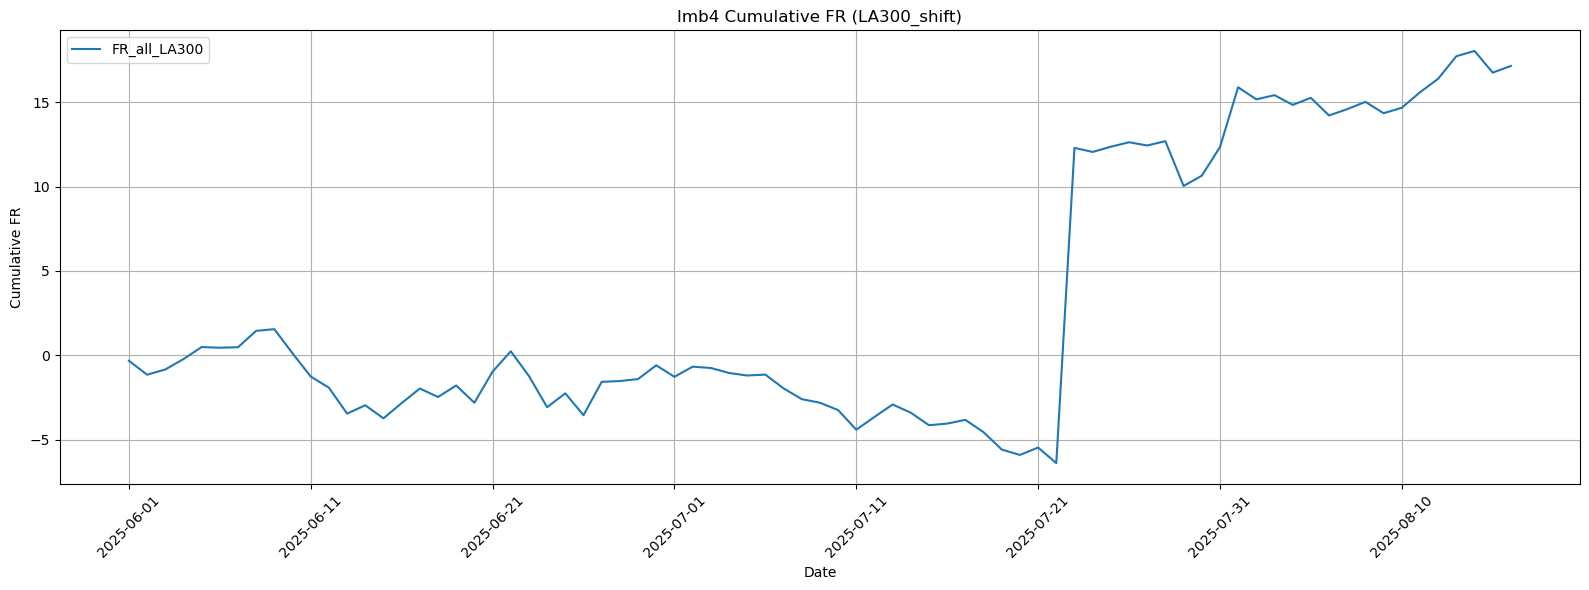

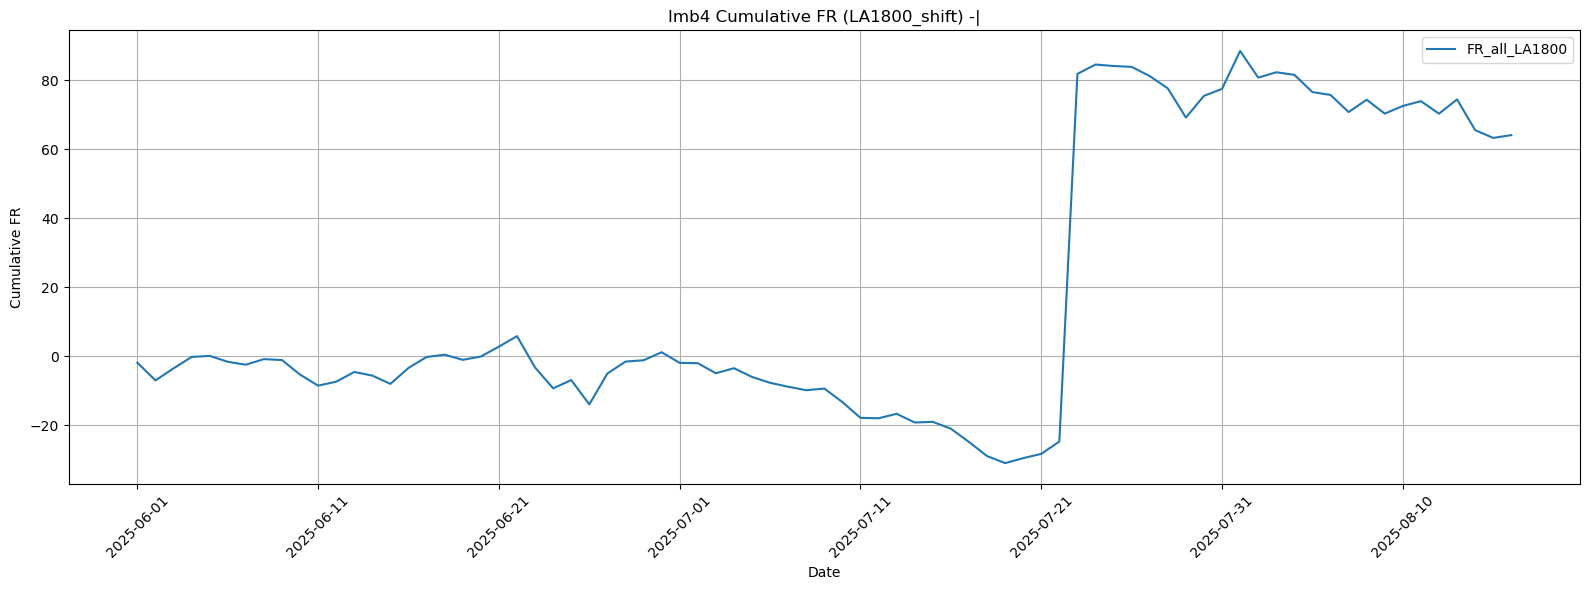

In [130]:
plot_cols('Imb4', df_merge)

In [122]:
def plot_cols(feat_col, feature_all_df):
    # # 假设你已经有以下变量
    # feat_col = 'Around3s_AvgPrc_minusclose'
    ret_cols = ['LA300', 'LA1800']


    df = feature_all_df.reset_index()

    # ---------- 全部时间点 (FR_all_*) ----------
    fr_all_results = {}
    for ret_col in ret_cols:
        sub_df = df[[feat_col, ret_col, 'date']].dropna()

        # 按date groupby，计算 FR = cov(x, y) / std(x)
        grouped = sub_df.groupby('date')
        mean_x = grouped[feat_col].transform('mean')
        mean_y = grouped[ret_col].transform('mean')
        std_x = grouped[feat_col].transform('std')

        cov_xy = ((sub_df[feat_col] - mean_x) * (sub_df[ret_col] - mean_y)).groupby(sub_df['date']).mean()
        std_x_daily = std_x.groupby(sub_df['date']).first()  # std(x)是一样的，随便取一个就行

        fr = cov_xy / std_x_daily.replace(0, np.nan)
        fr_all_results[f'FR_all_{ret_col}'] = fr

    # ---------- 特定时间点 (FR_{time}_{ret_col}) ----------
    fr_time_results = {}


    # 合并所有结果
    fr_df = pd.DataFrame(fr_all_results)
    cumulative_fr_df = fr_df.cumsum()

    # 分别提取 ret0e 和 ret1h 的 FR 列
    fr_0e_cols = [col for col in cumulative_fr_df.columns if 'LA300' in col]
    fr_1h_cols = [col for col in cumulative_fr_df.columns if 'LA1800' in col]
    

    # 画 ret0e_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_0e_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (LA300_shift)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()

    # 画 ret1h_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_1h_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (LA1800_shift) -|')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()
#     fr_df.to_parquet(f'/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/fr_save/{feat_col}.parquet', engine="pyarrow", compression="snappy")
    


In [ ]:
import pandas as pd
import numpy as np

def cvx_lws(vol):
    """
    实现cvx_lws指标计算
    vol: 输入的成交量序列
    """
    cumsum_vol = vol.cumsum()
    se_mean = cumsum_vol.mean()
    cumbffill = cumsum_vol.ffill().bfill()
    av_mean = (cumbffill.iloc[0] + cumbffill.iloc[-1]) / 2.0
    return (av_mean - se_mean) / se_mean

def get_intra900010(df, begDate, endDate):
    """
    获取指定日期范围内的因子数据
    df: 1分钟K线数据DataFrame，需包含'date'、'time'、'instrument'、'close'等列
    begDate, endDate: 日期范围
    """
    # 筛选日期范围内的数据
    mask = (df['date'] >= begDate) & (df['date'] <= endDate)
    filtered_df = df[mask].copy()
    # 按日期和股票分组计算cvx_lws因子
    # 首先计算20期移动窗口的cvx_lws值
    def calculate_group(group):
        group['cvx_vol'] = group['close'].rolling(window=20).apply(
            lambda x: -cvx_lws(x), raw=False
        )
        return group
    result_df = filtered_df.groupby(['date', 'instrument'], group_keys=False).apply(calculate_group)
    return result_df


